In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Suppress TensorFlow warnings
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Core libraries
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Pretrained Models
from tensorflow.keras.applications import EfficientNetB4, DenseNet121


2026-01-18 16:52:47.722528: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768755167.898070      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768755167.951143      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768755168.375031      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768755168.375085      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768755168.375088      55 computation_placer.cc:177] computation placer alr

In [2]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 2


In [3]:
DATASET_PATH = "/kaggle/input/oral-diseases"

classes = os.listdir(DATASET_PATH)
print(classes)


['Data caries', 'Mouth Ulcer', 'Tooth Discoloration', 'hypodontia', 'Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset', 'Gingivitis', 'Calculus']


In [4]:
DATASET_PATH = "/kaggle/input/oral-diseases"

CLASS_FOLDERS = {
    "Calculus": "Calculus",
    "Caries": "Data caries",
    "Gingivitis": "Gingivitis",
    "Mouth_Ulcer": "Mouth Ulcer",
    "Tooth_Discoloration": "Tooth Discoloration",
    "Hypodontia": "hypodontia"
}

classes = list(CLASS_FOLDERS.keys())
print(classes)


['Calculus', 'Caries', 'Gingivitis', 'Mouth_Ulcer', 'Tooth_Discoloration', 'Hypodontia']


In [5]:
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")

image_paths = []
labels = []

for label, folder in enumerate(classes):
    root_dir = os.path.join(DATASET_PATH, CLASS_FOLDERS[folder])

    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith(VALID_EXTENSIONS):
                image_paths.append(os.path.join(root, file))
                labels.append(label)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))


Total images: 12320


In [12]:
from collections import Counter
print(Counter(labels))


Counter({np.int64(3): 2806, np.int64(1): 2601, np.int64(2): 2349, np.int64(4): 2017, np.int64(0): 1296, np.int64(5): 1251})


In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)


In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(1.5843621399176955), 1: np.float64(0.789439958990132), 2: np.float64(0.8741308358166596), 3: np.float64(0.7317652649085293), 4: np.float64(1.0180135514790944), 5: np.float64(1.641353583799627)}


In [15]:
def preprocess_tf(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


In [16]:
def make_dataset(paths, labels, batch=8, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths))
        
    ds = ds.map(
        preprocess_tf,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


In [20]:
IMG_SIZE = 380

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val, y_val)
test_ds  = make_dataset(X_test, y_test)


I0000 00:00:1768735617.877373      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768735617.881257      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
base_model = EfficientNetB4(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(6, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
import tensorflow as tf

# Convert class weights dict to tensor
class_weight_tensor = tf.constant(
    [class_weight_dict[i] for i in range(len(class_weight_dict))],
    dtype=tf.float32
)

def weighted_sparse_cce(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    weights = tf.gather(class_weight_tensor, y_true)
    loss = tf.keras.losses.sparse_categorical_crossentropy(
        y_true, y_pred
    )
    return loss * weights


In [ ]:
model.compile(
    optimizer=Adam(1e-4),
    loss=weighted_sparse_cce,
    metrics=["accuracy"]
)


In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


In [ ]:
CHECKPOINT_PATH = "/kaggle/working/efficientnet_b4_best.keras"

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False


In [ ]:
model.compile(
    optimizer=Adam(3e-5),
    loss=weighted_sparse_cce,
    metrics=["accuracy"]
)


In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


In [ ]:
# Freeze full backbone
base_model.trainable = False

model.compile(
    optimizer=Adam(1e-3),  # HIGH LR
    loss=weighted_sparse_cce,
    metrics=["accuracy"]
)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks
)


In [ ]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks
)

In [ ]:
total_layers = len(base_model.layers)
unfreeze_from = int(total_layers * 0.6)  # unfreeze top 40%

for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False

for layer in base_model.layers[unfreeze_from:]:
    layer.trainable = True


In [ ]:
model.compile(
    optimizer=Adam(1e-4),   # this is critical
    loss=weighted_sparse_cce,
    metrics=["accuracy"]
)


In [ ]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


In [ ]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


In [ ]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


In [ ]:
def focal_loss(alpha=0.25, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=6)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return loss


In [ ]:
model.compile(
    optimizer=Adam(1e-4),
    loss=focal_loss(),
    metrics=["accuracy"]
)


In [ ]:
history_finetune1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


In [ ]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(test_ds), axis=1)
print(classification_report(y_test, y_pred, target_names=classes))


In [13]:
def preprocess_tf_aug(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.7, 1.3)
    img = tf.image.random_saturation(img, 0.7, 1.3)

    img = tf.cast(img, tf.float32) / 255.0
    return img, label


In [14]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(len(X_train)) \
    .map(preprocess_tf_aug, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(8).prefetch(tf.data.AUTOTUNE)


In [ ]:
def focal_loss(alpha=0.25, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=6)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return loss


In [ ]:
model.compile(
    optimizer=Adam(1e-4),
    loss=focal_loss(),
    metrics=["accuracy"]
)


In [ ]:
import os

os.listdir("/kaggle/working")


In [15]:
IMG_SIZE = 224


In [16]:
import tensorflow as tf

def preprocess_tf_aug(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.7, 1.3)
    img = tf.image.random_saturation(img, 0.7, 1.3)

    img = tf.cast(img, tf.float32) / 255.0
    return img, label


In [17]:
def preprocess_tf(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


In [18]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(len(X_train)) \
    .map(preprocess_tf_aug, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(16).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(16).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(16).prefetch(tf.data.AUTOTUNE)


In [19]:
def focal_loss(alpha=0.25, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=6)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return loss


In [20]:
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = DenseNet169(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(6, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-3),
    loss=focal_loss(),
    metrics=["accuracy"]
)


In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

CHECKPOINT_PATH = "/kaggle/working/densenet169_best.keras"

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.3),
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]


In [23]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks
)


Epoch 1/12


I0000 00:00:1768708272.640523     126 service.cc:152] XLA service 0x7f5ec4003f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768708272.640571     126 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768708272.640578     126 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768708277.219889     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/539 ━━━━━━━━━━━━━━━━━━━━ 44s 82ms/step - accuracy: 0.2188 - loss: 0.4956   

I0000 00:00:1768708293.071096     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


539/539 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5844 - loss: 0.1593
Epoch 1: val_loss improved from inf to 0.05236, saving model to /kaggle/working/densenet169_best.keras
539/539 ━━━━━━━━━━━━━━━━━━━━ 104s 125ms/step - accuracy: 0.5845 - loss: 0.1592 - val_accuracy: 0.8019 - val_loss: 0.0524 - learning_rate: 0.0010
Epoch 2/12
539/539 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7512 - loss: 0.0642
Epoch 2: val_loss improved from 0.05236 to 0.04972, saving model to /kaggle/working/densenet169_best.keras
539/539 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - accuracy: 0.7512 - loss: 0.0642 - val_accuracy: 0.7760 - val_loss: 0.0497 - learning_rate: 0.0010
Epoch 3/12
539/539 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7932 - loss: 0.0543
Epoch 3: val_loss improved from 0.04972 to 0.03864, saving model to /kaggle/working/densenet169_best.keras
539/539 ━━━━━━━━━━━━━━━━━━━━ 38s 70ms/step - accuracy: 0.7932 - loss: 0.0543 - val_accuracy: 0.8041 - val_loss: 0.0386 - learning_rate: 0.0010
Ep

In [24]:
total_layers = len(base_model.layers)
unfreeze_from = int(total_layers * 0.6)

for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False
for layer in base_model.layers[unfreeze_from:]:
    layer.trainable = True


In [25]:
model.compile(
    optimizer=Adam(1e-4),
    loss=focal_loss(),
    metrics=["accuracy"]
)


In [28]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9482 - loss: 0.0081
Epoch 1: val_loss did not improve from 0.01023
539/539 ━━━━━━━━━━━━━━━━━━━━ 53s 98ms/step - accuracy: 0.9482 - loss: 0.0081 - val_accuracy: 0.9410 - val_loss: 0.0103 - learning_rate: 9.0000e-06
Epoch 2/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9526 - loss: 0.0072
Epoch 2: val_loss did not improve from 0.01023
539/539 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.9526 - loss: 0.0072 - val_accuracy: 0.9399 - val_loss: 0.0104 - learning_rate: 9.0000e-06
Epoch 3/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9536 - loss: 0.0070
Epoch 3: val_loss did not improve from 0.01023
539/539 ━━━━━━━━━━━━━━━━━━━━ 52s 97ms/step - accuracy: 0.9536 - loss: 0.0070 - val_accuracy: 0.9421 - val_loss: 0.0103 - learning_rate: 9.0000e-06
Epoch 4/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9477 - loss: 0.0075
Epoch 4: val_loss did not improve from 0.01023
539/539 ━━━━━━━━━━━━━━━

In [29]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(test_ds), axis=1)
print(classification_report(y_test, y_pred, target_names=classes))


116/116 ━━━━━━━━━━━━━━━━━━━━ 39s 196ms/step
                     precision    recall  f1-score   support

           Calculus       0.73      0.69      0.71       195
             Caries       0.99      0.99      0.99       390
         Gingivitis       0.83      0.86      0.84       352
        Mouth_Ulcer       1.00      1.00      1.00       421
Tooth_Discoloration       1.00      1.00      1.00       303
         Hypodontia       0.99      0.97      0.98       187

           accuracy                           0.93      1848
          macro avg       0.92      0.92      0.92      1848
       weighted avg       0.93      0.93      0.93      1848



In [26]:
IMG_SIZE = 456


In [23]:
import tensorflow as tf

def preprocess_tf_aug(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.7, 1.3)
    img = tf.image.random_saturation(img, 0.7, 1.3)

    img = tf.cast(img, tf.float32) / 255.0
    return img, label


In [24]:
def preprocess_tf(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


In [27]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(len(X_train)) \
    .map(preprocess_tf_aug, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(8).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(8).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(8).prefetch(tf.data.AUTOTUNE)


In [26]:
def focal_loss(alpha=0.25, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=6)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return loss


In [27]:
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

base_model = EfficientNetB5(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(6, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-3),
    loss=focal_loss(),
    metrics=["accuracy"]
)


In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

CHECKPOINT_PATH = "/kaggle/working/efficientnet_b5_best.keras"

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.3),
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]


In [30]:
history_head2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks
)


Epoch 1/12


I0000 00:00:1768735720.282307     146 service.cc:152] XLA service 0x7c5bd8004d70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768735720.282377     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768735720.282386     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768735725.409690     146 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-18 11:28:55.235053: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 11:28:55.395957: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 11:28:56.719910: E external/local_xl

1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.2321 - loss: 0.9358
Epoch 1: val_loss improved from inf to 0.26927, saving model to /kaggle/working/efficientnet_b5_best.keras
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 243s 170ms/step - accuracy: 0.2321 - loss: 0.9356 - val_accuracy: 0.2895 - val_loss: 0.2693 - learning_rate: 0.0010
Epoch 2/12
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.2797 - loss: 0.3046
Epoch 2: val_loss improved from 0.26927 to 0.25654, saving model to /kaggle/working/efficientnet_b5_best.keras
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 175s 163ms/step - accuracy: 0.2797 - loss: 0.3046 - val_accuracy: 0.3285 - val_loss: 0.2565 - learning_rate: 0.0010
Epoch 3/12
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.2920 - loss: 0.2834
Epoch 3: val_loss did not improve from 0.25654
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 174s 161ms/step - accuracy: 0.2920 - loss: 0.2834 - val_accuracy: 0.3047 - val_loss: 0.2647 - learning_rate: 0.0010
Epoch 4/12
1078/1078 ━━━━━━━━━━━━━━

In [41]:
total_layers = len(base_model.layers)
unfreeze_from = int(total_layers * 0.65)  # unfreeze top 35%

for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False
for layer in base_model.layers[unfreeze_from:]:
    layer.trainable = True


In [ ]:
model.compile(
    optimizer=Adam(1e-4),
    loss=focal_loss(),
    metrics=["accuracy"]
)


In [43]:
history_fine2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20


2026-01-18 06:18:13.713497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 06:18:13.891046: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 06:18:14.504063: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 06:18:14.668636: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 06:18:15.253458: E external/local_xla/xla/stream_

1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.2979 - loss: 0.2763
Epoch 1: val_loss improved from 0.24561 to 0.24424, saving model to /kaggle/working/efficientnet_b5_best.keras
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 431s 316ms/step - accuracy: 0.2979 - loss: 0.2763 - val_accuracy: 0.3831 - val_loss: 0.2442 - learning_rate: 1.0000e-04
Epoch 2/20
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.3575 - loss: 0.2479
Epoch 2: val_loss improved from 0.24424 to 0.18679, saving model to /kaggle/working/efficientnet_b5_best.keras
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 322s 299ms/step - accuracy: 0.3575 - loss: 0.2479 - val_accuracy: 0.4340 - val_loss: 0.1868 - learning_rate: 1.0000e-04
Epoch 3/20
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.3943 - loss: 0.2248
Epoch 3: val_loss improved from 0.18679 to 0.16102, saving model to /kaggle/working/efficientnet_b5_best.keras
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 322s 299ms/step - accuracy: 0.3943 - loss: 0.2248 - val_accuracy: 0.5027 - 

In [31]:
total_layers = len(base_model.layers)
unfreeze_from = int(total_layers * 0.45)  # unfreeze top 55%

for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False
for layer in base_model.layers[unfreeze_from:]:
    layer.trainable = True


In [32]:
model.compile(
    optimizer=Adam(3e-5),   # lower LR
    loss=focal_loss(),
    metrics=["accuracy"]
)


In [33]:
history_fine2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15


2026-01-18 12:09:07.662821: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:09:07.835502: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:09:08.482311: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:09:08.625178: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:09:08.910479: E external/local_xla/xla/stream_

1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.3305 - loss: 0.2616
Epoch 1: val_loss improved from 0.23904 to 0.18212, saving model to /kaggle/working/efficientnet_b5_best.keras
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 477s 341ms/step - accuracy: 0.3305 - loss: 0.2616 - val_accuracy: 0.4551 - val_loss: 0.1821 - learning_rate: 3.0000e-05
Epoch 2/15
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.3907 - loss: 0.2203
Epoch 2: val_loss improved from 0.18212 to 0.15190, saving model to /kaggle/working/efficientnet_b5_best.keras
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 355s 329ms/step - accuracy: 0.3908 - loss: 0.2203 - val_accuracy: 0.4870 - val_loss: 0.1519 - learning_rate: 3.0000e-05
Epoch 3/15
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.4341 - loss: 0.1933
Epoch 3: val_loss improved from 0.15190 to 0.14201, saving model to /kaggle/working/efficientnet_b5_best.keras
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 354s 328ms/step - accuracy: 0.4341 - loss: 0.1933 - val_accuracy: 0.5022 - 

In [34]:
history_fine2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.7632 - loss: 0.0639
Epoch 1: val_loss improved from 0.04141 to 0.03700, saving model to /kaggle/working/efficientnet_b5_best.keras
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 353s 327ms/step - accuracy: 0.7632 - loss: 0.0639 - val_accuracy: 0.8252 - val_loss: 0.0370 - learning_rate: 3.0000e-05
Epoch 2/15
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.7734 - loss: 0.0586
Epoch 2: val_loss improved from 0.03700 to 0.03514, saving model to /kaggle/working/efficientnet_b5_best.keras
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 353s 327ms/step - accuracy: 0.7734 - loss: 0.0586 - val_accuracy: 0.8274 - val_loss: 0.0351 - learning_rate: 3.0000e-05
Epoch 3/15
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.7860 - loss: 0.0571
Epoch 3: val_loss improved from 0.03514 to 0.03355, saving model to /kaggle/working/efficientnet_b5_best.keras
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 352s 327ms/step - accuracy: 0.7860 - loss: 0.0571 - val_accuracy

In [35]:
import numpy as np

y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)


231/231 ━━━━━━━━━━━━━━━━━━━━ 43s 127ms/step


In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=classes,
    digits=4
))


                     precision    recall  f1-score   support

           Calculus     0.6683    0.7026    0.6850       195
             Caries     0.9437    0.9462    0.9449       390
         Gingivitis     0.8171    0.8125    0.8148       352
        Mouth_Ulcer     0.9856    0.9762    0.9809       421
Tooth_Discoloration     0.9502    0.9439    0.9470       303
         Hypodontia     0.9837    0.9679    0.9757       187

           accuracy                         0.9037      1848
          macro avg     0.8914    0.8915    0.8914      1848
       weighted avg     0.9052    0.9037    0.9044      1848



In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [18]:
MODEL_PATHS = {
    "EfficientNet-B4": "/kaggle/input/saved-models/efficientnet_b4_best.keras",
    "EfficientNet-B5": "/kaggle/input/saved-models/efficientnet_b5_best.keras",
    "DenseNet-169": "/kaggle/input/saved-models/densenet169_best (1).keras"
}

models = {}

for name, path in MODEL_PATHS.items():
    models[name] = load_model(path, compile=False)
    print(f"{name} loaded")


I0000 00:00:1768755429.019787      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768755429.023662      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


EfficientNet-B4 loaded
EfficientNet-B5 loaded
DenseNet-169 loaded


In [30]:
import tensorflow as tf

def preprocess_224(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def preprocess_380(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (380, 380))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def preprocess_456(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (456, 456))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


In [31]:
test_ds_224 = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .map(preprocess_224, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(16).prefetch(tf.data.AUTOTUNE)

test_ds_380 = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .map(preprocess_380, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(16).prefetch(tf.data.AUTOTUNE)

test_ds_456 = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .map(preprocess_456, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(8).prefetch(tf.data.AUTOTUNE)


In [32]:
test_datasets = {
    "EfficientNet-B4": test_ds_380,
    "EfficientNet-B5": test_ds_456,
    "DenseNet-169": test_ds_224
}


In [33]:
import tensorflow as tf

def preprocess(img_path, label, size):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (size, size))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_test_ds(size, batch):
    return tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
        .map(lambda x, y: preprocess(x, y, size),
             num_parallel_calls=tf.data.AUTOTUNE) \
        .batch(batch) \
        .prefetch(tf.data.AUTOTUNE)

test_datasets = {
    "EfficientNet-B4": make_test_ds(380, 16),
    "EfficientNet-B5": make_test_ds(456, 8),
    "DenseNet-169": make_test_ds(224, 16)
}


In [34]:
from tensorflow.keras.models import load_model

models = {
    "EfficientNet-B4": load_model(
        "/kaggle/input/saved-models/efficientnet_b4_best.keras", compile=False
    ),
    "EfficientNet-B5": load_model(
        "/kaggle/input/saved-models/efficientnet_b5_best.keras", compile=False
    ),
    "DenseNet-169": load_model(
        "/kaggle/input/saved-models/densenet169_best (1).keras", compile=False
    )
}


In [35]:
import numpy as np

predictions = {}

for name, model in models.items():
    print(f"Running inference for {name}")
    y_prob = model.predict(test_datasets[name], verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    predictions[name] = y_pred


Running inference for EfficientNet-B4


I0000 00:00:1768755940.437359     181 service.cc:152] XLA service 0x78b778005de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768755940.437411     181 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768755940.437419     181 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768755942.082325     181 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-18 17:05:50.379017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 17:05:50.525874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 17:05:50.804218: E external/local_xl

115/116 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step

2026-01-18 17:06:27.134000: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 17:06:27.271952: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 17:06:27.505345: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 17:06:27.643737: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 17:06:27.905845: E external/local_xla/xla/stream_

116/116 ━━━━━━━━━━━━━━━━━━━━ 60s 312ms/step
Running inference for EfficientNet-B5


2026-01-18 17:06:47.665191: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 17:06:47.827807: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 17:06:49.150816: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 17:06:49.293475: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 17:06:49.572856: E external/local_xla/xla/stream_

231/231 ━━━━━━━━━━━━━━━━━━━━ 58s 149ms/step
Running inference for DenseNet-169
116/116 ━━━━━━━━━━━━━━━━━━━━ 46s 226ms/step


In [36]:
from sklearn.metrics import classification_report

for name, y_pred in predictions.items():
    print(f"\n===== {name} Classification Report =====\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=classes,
        digits=3
    ))



===== EfficientNet-B4 Classification Report =====

                     precision    recall  f1-score   support

           Calculus      0.579     0.774     0.662       195
             Caries      0.898     0.923     0.910       390
         Gingivitis      0.832     0.688     0.753       352
        Mouth_Ulcer      0.949     0.933     0.941       421
Tooth_Discoloration      0.919     0.904     0.912       303
         Hypodontia      0.967     0.947     0.957       187

           accuracy                          0.864      1848
          macro avg      0.857     0.862     0.856      1848
       weighted avg      0.874     0.864     0.866      1848


===== EfficientNet-B5 Classification Report =====

                     precision    recall  f1-score   support

           Calculus      0.668     0.703     0.685       195
             Caries      0.944     0.946     0.945       390
         Gingivitis      0.817     0.812     0.815       352
        Mouth_Ulcer      0.986     0.9

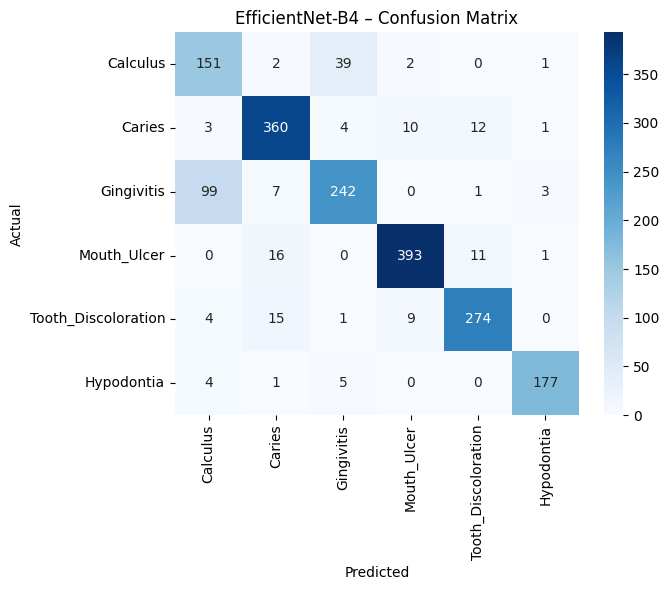

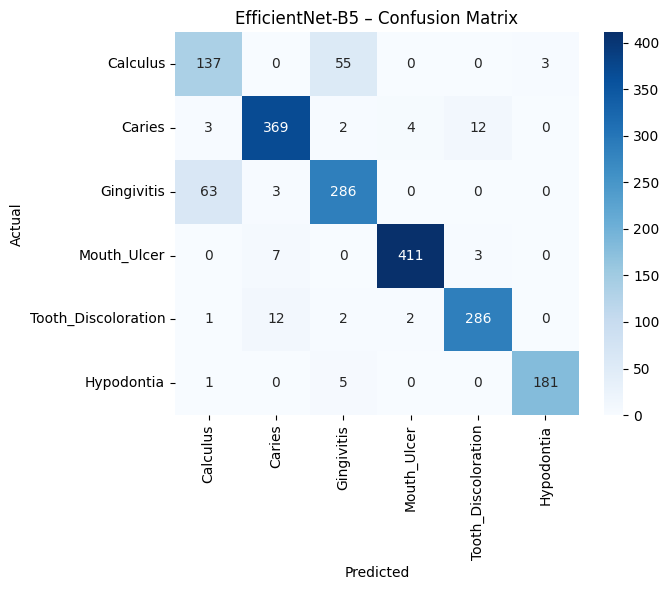

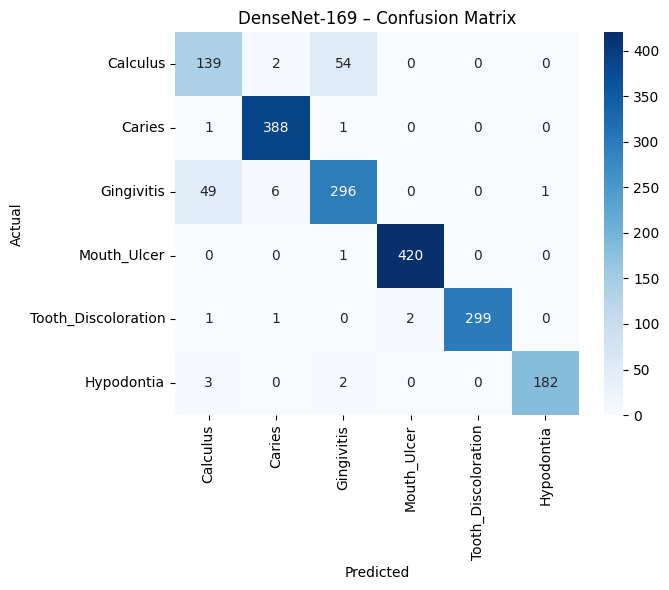

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


In [38]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results = []

for name, y_pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted")
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Macro F1,Weighted F1
0,EfficientNet-B4,0.864177,0.855855,0.866117
1,EfficientNet-B5,0.903680,0.891404,0.904378
2,DenseNet-169,0.932900,0.919104,0.932837


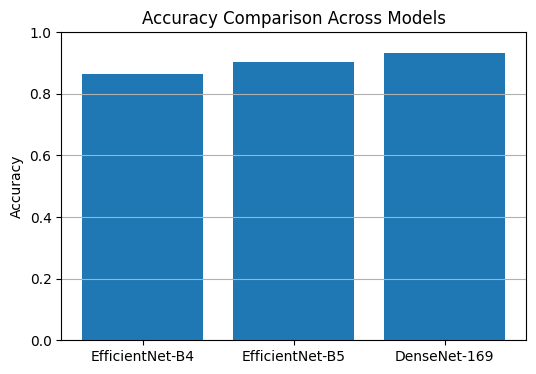

In [39]:
plt.figure(figsize=(6,4))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Across Models")
plt.grid(axis="y")
plt.show()


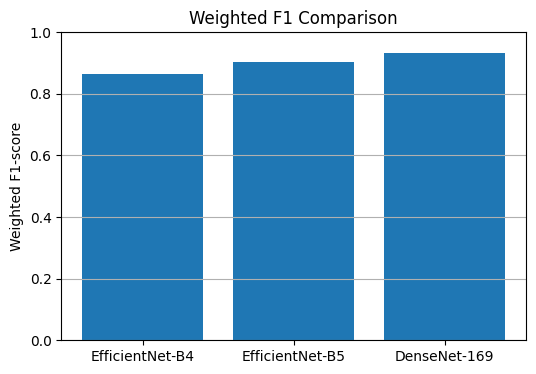

In [40]:
plt.figure(figsize=(6,4))
plt.bar(results_df["Model"], results_df["Weighted F1"])
plt.ylim(0,1)
plt.ylabel("Weighted F1-score")
plt.title("Weighted F1 Comparison")
plt.grid(axis="y")
plt.show()
